[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [1]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

Cloning into 'Thesis'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 132 (delta 71), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 6.23 MiB | 5.75 MiB/s, done.
Resolving deltas: 100% (71/71), done.


In [41]:
from obspy import read, Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import stft

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import numpy as np
import pandas as pd

# KVG Catalog

## Stations

### Retrieve Coordinates

In [6]:
client = Client("https://geofon.gfz-potsdam.de")
tstart = UTCDateTime("2015-07-01 00:00:00")
tend   = UTCDateTime("2016-07-31 00:00:00")

inv = client.get_stations(network="X9",  starttime=tstart, endtime=tend, channel="*HN")
# print(inv)
nsta = np.shape(inv)[1]

# stla = np.zeros(nsta)
# stlo = np.zeros(nsta)
coordinates_for_station = {}
stname = []

for i in range(0,nsta):
    coordinates_for_station[inv[0][i].code] = [inv[0][i].latitude,inv[0][i].longitude]

## Catalog

In [7]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
print(f"Time range: {catalog['time'].min()} to {catalog['time'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} – {catalog['mag'].max():.1f}")
catalog.head()

Loaded 11209 events
Time range: 2015-08-03 14:56:47.810000+00:00 to 2016-07-04 21:46:56.760000+00:00
Magnitude range: 0.0 – 3.1


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


## Phase Data

In [8]:
stations_for_event = {}
Event_per_station = {}
i=0
with open("/content/Thesis/KVG_phase_data.txt", "r", encoding="UTF-8") as f:
    date = -1
    line = f.readline()

    while line != "":
        check = line[:2]
        match check:
            case "X9":
                datas = line.split(",")
                #                                              NOME STAZIONE     P TIME   S TIME
                stations_for_event.setdefault(f"Event {i}", {})[datas[0][3:]] = (datas[1],datas[2])
                Event_per_station.setdefault(datas[0][3:], []).append(f"Event {i}")

            case "D0":
                pass

            case _:
                date = line.split(",")[0]
                i+=1
        line = f.readline()

# Preparing Dataset

## Pre e Post Events

In [11]:
# Event_per_station Dizionario dove per chiave ho il nome della stazione e valore la lista degli eventi registrati
Stazioni_da_usare = ["SV13", "SV6", "SV7", "IR2", "IR3", "IR4", "IR6"]

# Maschera per PRE-Eruzione
start = pd.Timestamp("2016-03-20", tz="UTC")
end   = pd.Timestamp("2016-04-20", tz="UTC")

mask = (catalog["time"] >= start) & (catalog["time"] <= end)
catalog_PRE = catalog[mask].index.tolist()
PRE_Eruption = []

for stazione in Stazioni_da_usare:
  PRE_Eruption += [(stazione, ev) for ev in catalog_PRE if ev in set(Event_per_station[stazione])]

# Maschera per POST-Eruzione
start = pd.Timestamp("2016-04-21", tz="UTC")
# end   = pd.Timestamp("2016-06-05", tz="UTC")

mask = (catalog["time"] >= start) #& (catalog["time"] <= end)
catalog_POST = catalog[mask].index.tolist()
POST_Eruption = []

for stazione in Stazioni_da_usare:
  POST_Eruption += [(stazione, ev) for ev in catalog_POST if ev in set(Event_per_station[stazione])]

print(len(PRE_Eruption),len(POST_Eruption))

1451 1502


## Retrieve Data and Filtering

In [ ]:
# lunghezza temporale dell'onda
# 23 min per 2050
# 34 min per 3000 circa
pre_time   = 2
Post_time  = 18

Events = []
Dataset_By_Event   = {}
Dataset_By_Station = {}
labels = []                       # 0 = pre, 1 = post
POST_set = set(E for (St, E) in POST_Eruption)
n = len(PRE_Eruption) + len(POST_Eruption)
for index, Tmp in enumerate(PRE_Eruption + POST_Eruption):
    St, E = Tmp
    T = UTCDateTime(stations_for_event[E][St][0])
    try:
        Reg = client.get_waveforms(
            network="X9",
            station=St,
            location="*",
            channel="*",
            starttime=T - pre_time,
            endtime=T + Post_time)

        pos = len(Events)                 # indice reale in Events
        Events.append((St, E, Reg))
        labels.append(1 if E in POST_set else 0)
        Dataset_By_Station.setdefault(St, []).append(pos)
        Dataset_By_Event.setdefault(E, []).append(pos)

    except FDSNNoDataException:
        print(f"Errore per {E} nella stazione {St}\n")
        continue
    if not (index + 1) % 50: print(f"{index + 1}: {((index + 1)/n * 100):.2f}%  Fatti. ")

In [13]:
# Smoothing
for _, _, st in Events:
  for tr in st:

    tr.detrend("demean")
    tr.detrend("linear")

    tr.filter(
        "bandpass",
        freqmin=1,
        freqmax=20,
        corners=4,
        zerophase=True)

In [75]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
groups_ev = np.array([E for (St, E, D) in Events])   # il gruppo è l'evento

def split_per_gruppo(groups):
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.25)
    tr, tmp = next(gss1.split(X, y, groups))

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50)
    v, te = next(gss2.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

# CNN1D

In [61]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [62]:
train_ds = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

In [63]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # In caso prova anche un Flatten
            nn.AdaptiveAvgPool1d(1),   # riduce l'asse temporale a 1
        )
        # self.dropout = nn.Dropout(0.3)
        self.Dropout = nn.Dropout(0.3)
        self.lin = nn.Linear(128, output_classes)

    def forward(self, x):            # x: (batch, in_channels, lunghezza)
        x = self.features(self.Dropout(x))
        x = x.flatten(1)
        return self.lin(x)

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
model = CNN().to(device)
Using = "CNN1D"

crit = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10)

In [65]:
history = {"train_loss": [],
           "val_loss": [],
           "train_acc": [],
           "val_acc": []}

pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)

    val_loss = tot_loss / total
    val_acc  = correct / total

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}: \ntrain_loss={train_loss:.4f} \ntrain_acc={train_acc:.4f} \nval_loss={val_loss:.4f} \nval_acc={val_acc:.3f}")

Training:  25%|██▌       | 25/100 [04:06<15:20, 12.27s/it]


Epoch 25: 
train_loss=0.4986 
train_acc=0.7632 
val_loss=0.8276 
val_acc=0.551


Training:  50%|█████     | 50/100 [07:58<07:49,  9.40s/it]


Epoch 50: 
train_loss=0.4205 
train_acc=0.8044 
val_loss=0.7215 
val_acc=0.613


Training:  75%|███████▌  | 75/100 [11:51<03:56,  9.45s/it]


Epoch 75: 
train_loss=0.3803 
train_acc=0.8240 
val_loss=0.7030 
val_acc=0.624


Training: 100%|██████████| 100/100 [15:30<00:00,  9.30s/it]


Epoch 100: 
train_loss=0.3899 
train_acc=0.8258 
val_loss=0.7283 
val_acc=0.619


# CNN2D

In [76]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [77]:
train_ds = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

In [78]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),   # riduce l'asse temporale a 1
        )
        self.Dropout = nn.Dropout(0.3)
        self.lin = nn.Linear(128, output_classes)

    def forward(self, x):
        x = self.features(self.Dropout(x))
        x = x.flatten(1)
        return self.lin(x)

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
model = CNN2D().to(device)
Using = "CNN2D"
crit = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10)

In [80]:
history = {"train_loss": [],
           "val_loss": [],
           "train_acc": [],
           "val_acc": []}

pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    model.eval()
    tot_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += x.size(0)

    val_loss = tot_loss / total
    val_acc  = correct / total

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}: \ntrain_loss={train_loss:.4f} \ntrain_acc={train_acc:.4f} \nval_loss={val_loss:.4f} \nval_acc={val_acc:.3f}")

Training:  25%|██▌       | 25/100 [06:05<17:58, 14.38s/it]


Epoch 25: 
train_loss=0.3505 
train_acc=0.8467 
val_loss=0.7196 
val_acc=0.616


Training:  50%|█████     | 50/100 [12:20<12:34, 15.09s/it]


Epoch 50: 
train_loss=0.2142 
train_acc=0.9138 
val_loss=0.7950 
val_acc=0.622


Training:  75%|███████▌  | 75/100 [18:25<06:04, 14.59s/it]


Epoch 75: 
train_loss=0.1759 
train_acc=0.9290 
val_loss=0.9016 
val_acc=0.610


Training: 100%|██████████| 100/100 [24:39<00:00, 14.79s/it]


Epoch 100: 
train_loss=0.1598 
train_acc=0.9428 
val_loss=0.8849 
val_acc=0.610


# Results Plots

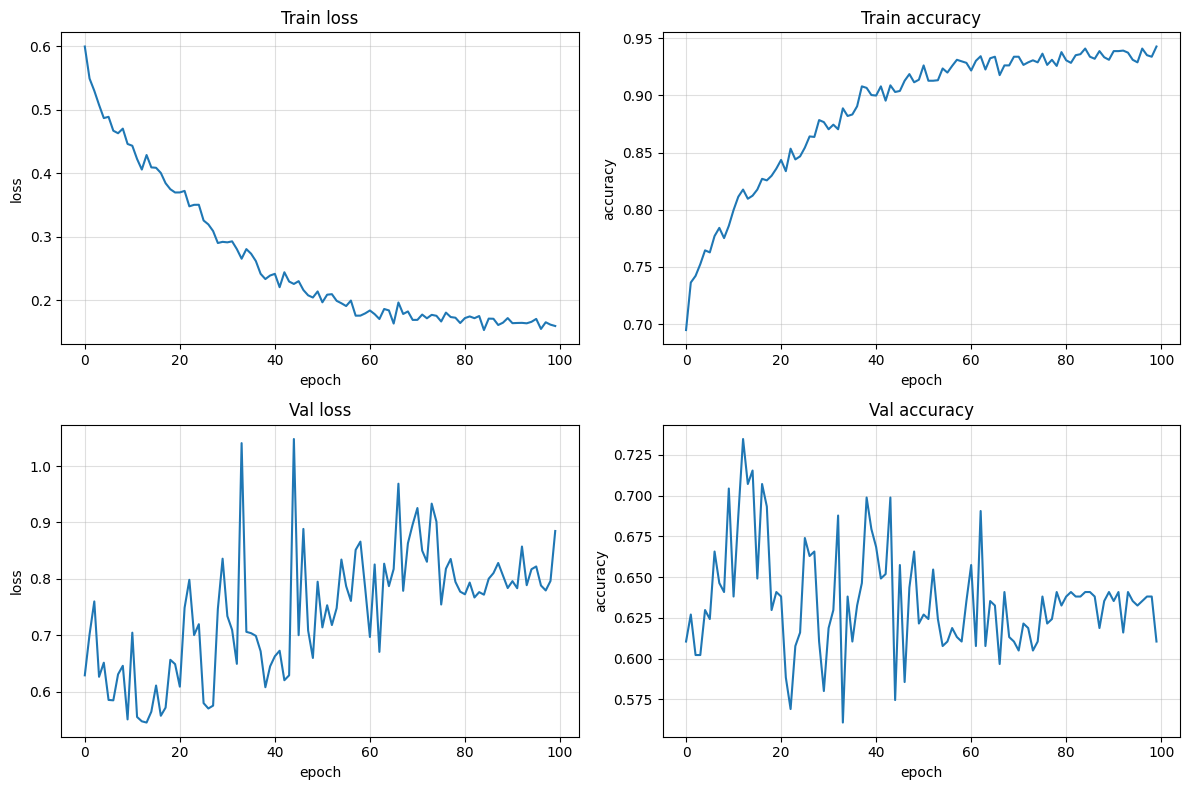

In [81]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(history["train_loss"])
ax[0, 0].set_title("Train loss")
ax[0, 0].set_xlabel("epoch"); ax[0, 0].set_ylabel("loss")
ax[0, 0].grid(alpha = 0.4)

ax[0, 1].plot(history["train_acc"])
ax[0, 1].set_title("Train accuracy")
ax[0, 1].set_xlabel("epoch"); ax[0, 1].set_ylabel("accuracy")
ax[0, 1].grid(alpha = 0.4)

ax[1, 0].plot(history["val_loss"])
ax[1, 0].set_title("Val loss")
ax[1, 0].set_xlabel("epoch"); ax[1, 0].set_ylabel("loss")
ax[1, 0].grid(alpha = 0.4)

ax[1, 1].plot(history["val_acc"])
ax[1, 1].set_title("Val accuracy")
ax[1, 1].set_xlabel("epoch"); ax[1, 1].set_ylabel("accuracy")
ax[1, 1].grid(alpha = 0.4)

fig.tight_layout()
fig.savefig(f"{Using}: Train and Validation set during Training.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:
def get_preds(model, loader):
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

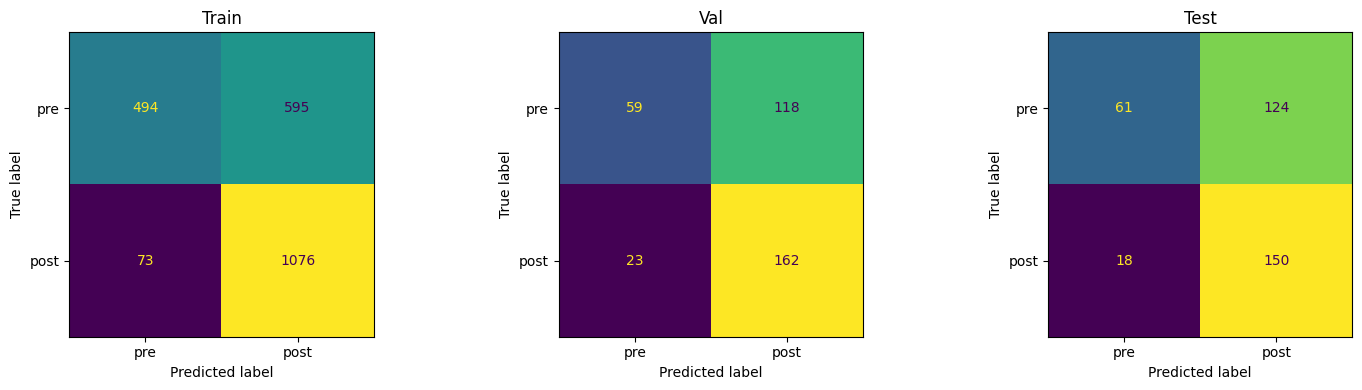

In [83]:
loaders = {"Train": train_loader, "Val": val_loader, "Test": test_loader}
labels  = ["pre", "post"]        # 0 = pre, 1 = post
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False)
    ax.set_title(name)

fig.tight_layout()
fig.savefig(f"{Using}: Confusion Matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [84]:
model.eval()
yt, yp = get_preds(model, test_loader)
test_acc = (yt == yp).mean()
print(f"Test accuracy: {test_acc:.4f}")
# print(history)

Test accuracy: 0.5977
